**Carson Plett || 501042248 || ELE888 - Lab 4**

 **Q1. Write a function to create x and y values that follows the given function
above. Provide initial plot of the function.**

The function and its plot is provided below.

In [1]:
import numpy as np

def function_y(x):
  return (0.2*x**4) + (2*x**3) + (0.1*x**2) + 10

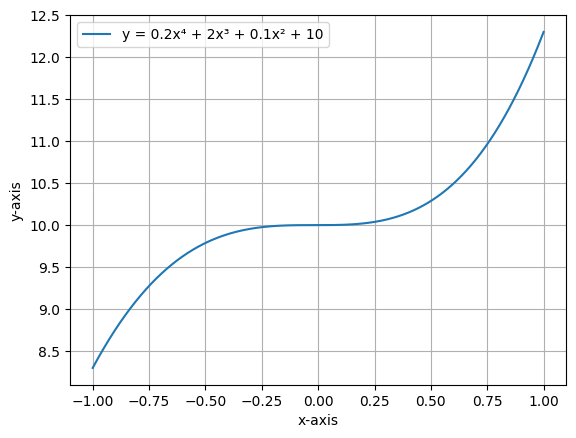

In [2]:
import matplotlib.pyplot as plt

x = np.linspace(-1, 1, 30000)
y = function_y(x)

plt.plot(x, y, label='y = 0.2x⁴ + 2x³ + 0.1x² + 10')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.grid(True)
plt.legend()
plt.show()

Write a function that accepts an argument to indicate shuffling. Based on the argument, function has to return the shuffled data or data without shuffling.

**Q2. Submit the above function in your code.**

Write a function to split the data into train, validation, and test sets. The function should be able to accept the data and ratios of train, validation, and test data.

**Q3. Submit the above function in your code.**

Write a function to scale the data between 0 and 1.

**Q4. Submit the above function in your code.**

Write a function that accepts actual target and predicted values to calculate mean absolute error (MAE), mean square error(MSE), root mean square error (RMSE), and r2 score.

**Q5. Submit the above function in your code.**

All these functions are provided below.


In [11]:
from sklearn.model_selection import train_test_split

def get_dataset(shuffle):
  x = np.random.uniform(-1, 1, 30000)
  y = function_y(x)
  if shuffle:
    indices = np.random.permutation(len(x))
    x = x[indices]
    y = y[indices]
  return x, y

def split_dataset(x, y, train_ratio, val_ratio, test_ratio):
    x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=train_ratio, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, train_size=val_ratio/(val_ratio + test_ratio), random_state=42)
    return x_train, y_train, x_val, y_val, x_test, y_test

def scale_dataset(x_train, y_train, x_val, y_val, x_test, y_test):
    x_min, x_max = np.min(x_train), np.max(x_train)
    y_min, y_max = np.min(y_train), np.max(y_train)
    x_train = (x_train - x_min) / (x_max - x_min)
    y_train = (y_train - y_min) / (y_max - y_min)
    x_val = (x_val - x_min) / (x_max - x_min)
    y_val = (y_val - y_min) / (y_max - y_min)
    x_test = (x_test - x_min) / (x_max - x_min)
    y_test = (y_test - y_min) / (y_max - y_min)
    return x_train, y_train, x_val, y_val, x_test, y_test

def plot_dataset(x, y):
  plt.plot(x, y, label='y = 0.2x^4 + 2x^3 + 0.1x^2 + 10')
  plt.xlabel('x-axis')
  plt.ylabel('y-axis')
  plt.grid(True)
  plt.legend()
  plt.show()

def error_calc(target, predicted):
  MAE = np.sum(np.abs(target - predicted))/len(target)
  MSE = np.sum((target - predicted)**2)/len(target)
  RMSE = MSE**0.5
  numer = np.sum((target - predicted)**2)
  denom = np.sum((target - np.mean(target))**2)
  R2 = 1 - numer/denom
  error = [MAE, MSE, RMSE, R2]
  return error

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

def build_model_1(input, activ_func):
  model = keras.models.Sequential([
    layers.Input(shape = input),
    layers.Dense(12, activation = activ_func),
    layers.Dense(8, activation = activ_func),
    layers.Dense(4, activation = activ_func),
    layers.Dense(1)
  ])
  model.compile(optimizer = 'adam', loss = 'mse')
  return model

def build_model_2(input, activ_func):
  model = keras.models.Sequential([
    layers.Input(shape = input),
    layers.Dense(24, activation = activ_func),
    layers.Dense(1)
  ])
  model.compile(optimizer = 'adam', loss = 'mse')
  return model

def plot_comparison(x_test, y_test, y_pred):
  plt.scatter(x_test, y_test, label='Actual Data', s=1)
  plt.scatter(x_test, y_pred, label='Predicted Data', s=1, color='red')
  plt.title('Neural Network Predictions vs Actual Data')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.legend()
  plt.show()

**Case 1**

Data - Shuffled and unscaled

NN Structure - Structure 1

Activation Function - Relu

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 76.1225 - val_loss: 0.1881
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1450 - val_loss: 0.0608
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0504 - val_loss: 0.0221
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0157 - val_loss: 0.0036
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0029 - val_loss: 0.0017
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0011 - val_loss: 8.5915e-04
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.5550e-04 - val_loss: 7.4469e-04
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.0401e-04 - val_loss: 7.0679e-04
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 7.5468e-04 - val_loss: 7.1904e-04
Epoch 12/20
750/750 ━━━

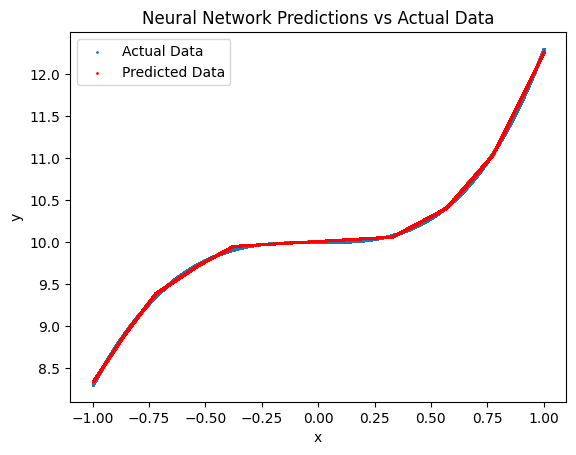

MAE:  0.0173710671257
MSE:  0.000457373728732458
RMSE: 0.021386297686426654
R2:   0.9992019514783245


In [10]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(True)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'relu'
case_1 = build_model_1(x_train.shape[1:], activation_function)
case_1.summary()

# Train the model
history = case_1.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_1.evaluate(x_test, y_test)
# Visualize
y_pred = case_1.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

Data - Unshuffled and unscaled

NN Structure - Structure 1

Activation Function - Relu

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 61.6062 - val_loss: 0.2291
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1760 - val_loss: 0.0610
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0554 - val_loss: 0.0492
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0487 - val_loss: 0.0443
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0429 - val_loss: 0.0314
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0266 - val_loss: 0.0132
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0106 - val_loss: 0.0049
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0016 - val_loss: 7.1556e-04
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms

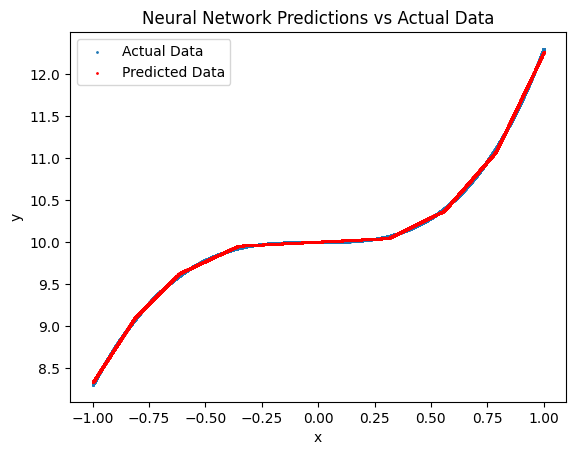

MAE:  0.012207552685876295
MSE:  0.00021224886443101172
RMSE: 0.014568763311654553
R2:   0.9996339942126939


In [12]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(False)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'relu'
case_1 = build_model_1(x_train.shape[1:], activation_function)
case_1.summary()

# Train the model
history = case_1.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_1.evaluate(x_test, y_test)
# Visualize
y_pred = case_1.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

**Case 2**

Data - Shuffled and unscaled

NN Structure - Structure 2

Activation Function - Relu

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                     │ (None, 24)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              25 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 73.4645 - val_loss: 0.4664
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1656 - val_loss: 0.0668
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0633 - val_loss: 0.0496
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0487 - val_loss: 0.0418
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0420 - val_loss: 0.0380
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0372 - val_loss: 0.0317
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0304 - val_loss: 0.0223
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0204 - val_loss: 0.0127
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0114 - val_loss: 0.0069
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0063 - val_loss: 0.0044
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0043 - val_loss: 0.0030
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/ste

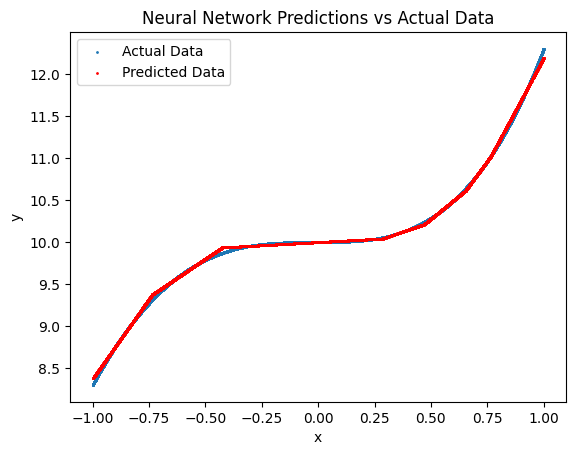

MAE:  0.016012612208596146
MSE:  0.0005406602205063706
RMSE: 0.023252101421298906
R2:   0.9990509697684654


In [13]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(True)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'relu'
case_2 = build_model_2(x_train.shape[1:], activation_function)
case_2.summary()

# Train the model
history = case_2.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_2.evaluate(x_test, y_test)
# Visualize
y_pred = case_2.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

Data - Unshuffled and unscaled

NN Structure - Structure 2

Activation Function - Relu

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 24)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              25 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 72.0177 - val_loss: 0.3100
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1239 - val_loss: 0.0763
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0705 - val_loss: 0.0661
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0597 - val_loss: 0.0594
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0563 - val_loss: 0.0553
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0529 - val_loss: 0.0504
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0475 - val_loss: 0.0423
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0380 - val_loss: 0.0328
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0278 - val_loss: 0.0221
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0188 - val_loss: 0.0149
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0134 - val_loss: 0.0106
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/ste

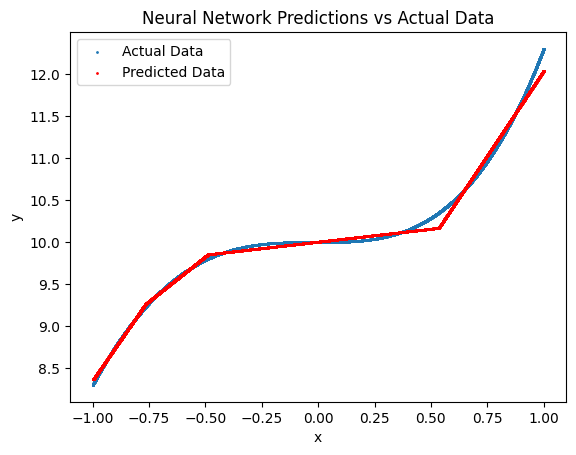

MAE:  0.04088812546862104
MSE:  0.0033924466272382235
RMSE: 0.05824471329861813
R2:   0.9941495474709635


In [14]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(False)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'relu'
case_2 = build_model_2(x_train.shape[1:], activation_function)
case_2.summary()

# Train the model
history = case_2.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_2.evaluate(x_test, y_test)
# Visualize
y_pred = case_2.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

**Case 3**

Data - Shuffled and unscaled

NN Structure - Structure 1

Activation Function - Tanh

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 66.9970 - val_loss: 21.7731
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 16.2051 - val_loss: 5.1744
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.6372 - val_loss: 1.0961
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8836 - val_loss: 0.5973
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5738 - val_loss: 0.5396
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3571 - val_loss: 0.2545
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2269 - val_loss: 0.1956
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1809 - val_loss: 0.1609
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1313 - val_loss: 0.0764
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0610 - val_loss: 0.0289
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0237 - val_loss: 0.0132
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/s

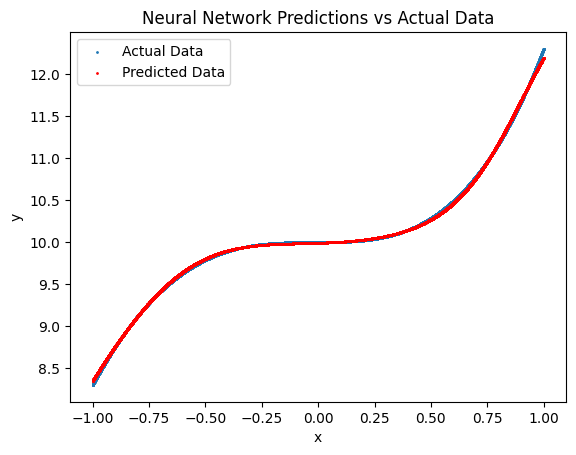

MAE:  0.013062293618952083
MSE:  0.00030978938707040875
RMSE: 0.017600834840154848
R2:   0.9994652074444155


In [15]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(True)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'tanh'
case_3 = build_model_1(x_train.shape[1:], activation_function)
case_3.summary()

# Train the model
history = case_3.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_3.evaluate(x_test, y_test)
# Visualize
y_pred = case_3.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

Data - Unshuffled and unscaled

NN Structure - Structure 1

Activation Function - Tanh

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 57.6672 - val_loss: 13.5250
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.8330 - val_loss: 2.5042
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.8332 - val_loss: 0.6680
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6519 - val_loss: 0.5542
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4963 - val_loss: 0.2701
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2700 - val_loss: 0.1902
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1999 - val_loss: 0.1574
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1582 - val_loss: 0.1247
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1067 - val_loss: 0.0352
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0306 - val_loss: 0.0129
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0123 - val_loss: 0.0054
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/st

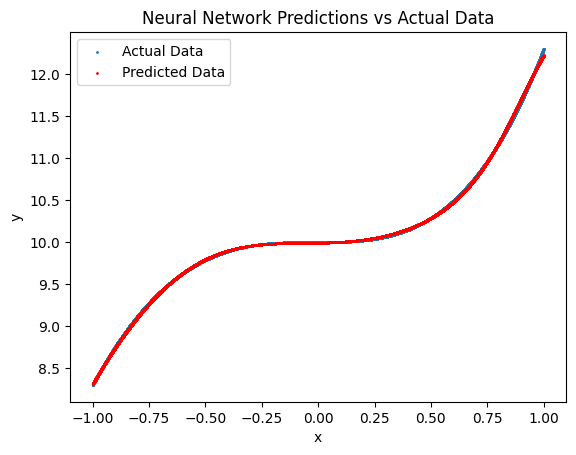

MAE:  0.009778401852148715
MSE:  0.00016657143075326543
RMSE: 0.012906255489229454
R2:   0.9997083576186144


In [16]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(False)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'tanh'
case_3 = build_model_1(x_train.shape[1:], activation_function)
case_3.summary()

# Train the model
history = case_3.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_3.evaluate(x_test, y_test)
# Visualize
y_pred = case_3.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

**Case 4**

Data - Shuffled and scaled

NN Structure - Structure 1

Activation Function - Relu

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0359 - val_loss: 0.0057
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0054 - val_loss: 0.0054
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0052 - val_loss: 0.0055
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0054 - val_loss: 0.0057
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0052 - val_loss: 0.0053
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0055 - val_loss: 0.0056
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

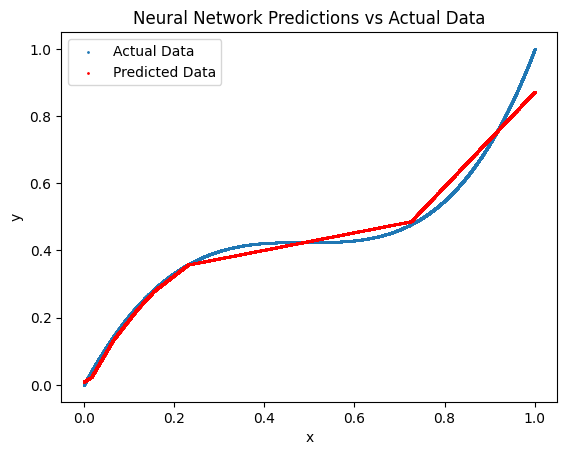

MAE:  0.02116352859315365
MSE:  0.0007728223244169388
RMSE: 0.02779968209201211
R2:   0.9783767785775975


In [17]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(True)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)
# Scale the dataset
x_train, y_train, x_val, y_val, x_test, y_test = scale_dataset(x_train, y_train, x_val, y_val, x_test, y_test)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'relu'
case_1 = build_model_1(x_train.shape[1:], activation_function)
case_1.summary()

# Train the model
history = case_1.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_1.evaluate(x_test, y_test)
# Visualize
y_pred = case_1.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

Data - Unshuffled and scaled

NN Structure - Structure 1

Activation Function - Relu

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                     │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0073 - val_loss: 0.0030
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 7.6112e-04 - val_loss: 3.6771e-04
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.0560e-04 - val_loss: 1.8779e-04
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.3753e-04 - val_loss: 7.2146e-05
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 6.9303e-05 - val_loss: 4.5910e-05
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.9622e-05 - val_loss: 3.4759e-05
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.7804e-05 - val_loss: 3.1601e-05
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.7340e-05 - val_loss: 2.8123e-05
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.6830e-05 - val_loss: 2.3254e-05
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.2312e-05 - v

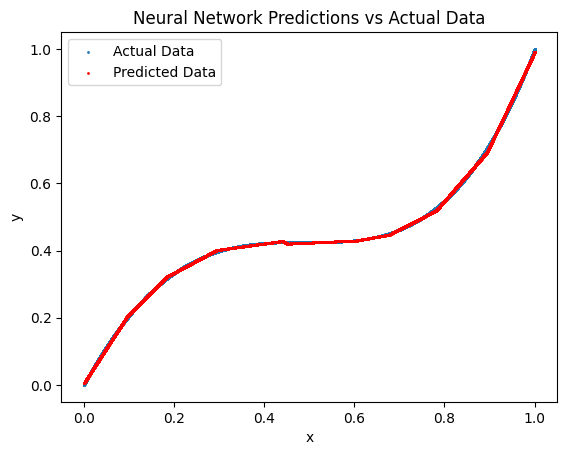

MAE:  0.002495785123249516
MSE:  1.041240962717736e-05
RMSE: 0.003226826556723705
R2:   0.9997153004328302


In [18]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(False)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)
# Scale the dataset
x_train, y_train, x_val, y_val, x_test, y_test = scale_dataset(x_train, y_train, x_val, y_val, x_test, y_test)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'relu'
case_1 = build_model_1(x_train.shape[1:], activation_function)
case_1.summary()

# Train the model
history = case_1.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_1.evaluate(x_test, y_test)
# Visualize
y_pred = case_1.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

**Case 5**

Data - Shuffled and scaled

NN Structure - Structure 1

Activation Function - Tanh

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0209 - val_loss: 0.0074
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0071 - val_loss: 0.0074
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0067 - val_loss: 0.0062
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0053 - val_loss: 0.0032
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0016 - val_loss: 3.2445e-04
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.5316e-04 - val_loss: 2.8166e-04
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.1381e-04 - val_loss: 2.9638e-04
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 3.2785e-04 - val_loss: 3.9699e-04
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 2.6446e-04 - val_loss: 3.5260e-04
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.3390e-04 - val_loss: 5.4750e-04
Epoch 12

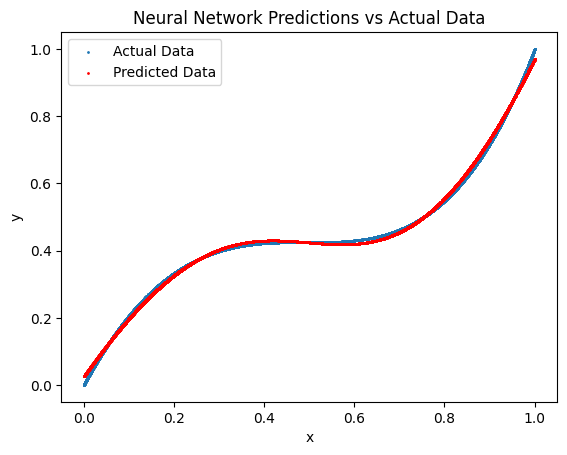

MAE:  0.007524943118572187
MSE:  7.881230132221538e-05
RMSE: 0.00887762926248981
R2:   0.9978286755787275


In [19]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(True)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)
# Scale the dataset
x_train, y_train, x_val, y_val, x_test, y_test = scale_dataset(x_train, y_train, x_val, y_val, x_test, y_test)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'tanh'
case_1 = build_model_1(x_train.shape[1:], activation_function)
case_1.summary()

# Train the model
history = case_1.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_1.evaluate(x_test, y_test)
# Visualize
y_pred = case_1.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

Data - Unshuffled and scaled

NN Structure - Structure 1

Activation Function - Tanh

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                     │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0822 - val_loss: 0.0084
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0076 - val_loss: 0.0077
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0064 - val_loss: 0.0059
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0056 - val_loss: 0.0036
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0024 - val_loss: 6.2209e-04
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.7943e-04 - val_loss: 4.5558e-04
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4.3907e-04 - val_loss: 4.2607e-04
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.8630e-04 - val_loss: 3.0999e-04
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.2638e-04 - val_loss: 2.4769e-04
Epoch 12/20
750/

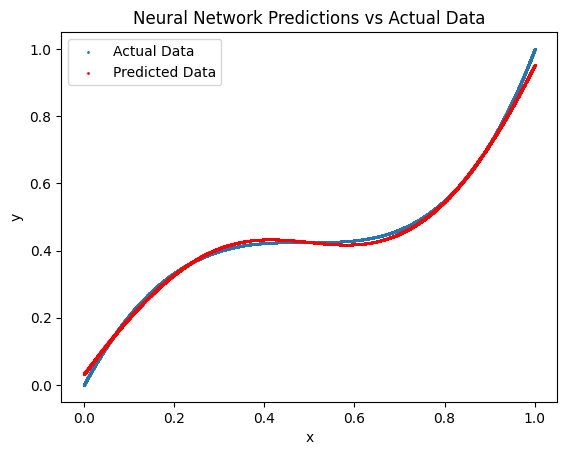

MAE:  0.008669129491938576
MSE:  0.00012764354813054362
RMSE: 0.011297944420581277
R2:   0.9964934065169723


In [20]:
train_ratio = 0.3
val_ratio = 0.2
test_ratio = 0.5
num_epochs = 20
num_batch = 12

# Get shuffled dataset
x, y = get_dataset(False)
# Split the dataset
x_train, y_train, x_val, y_val, x_test, y_test = split_dataset(x, y, train_ratio, val_ratio, test_ratio)
# Scale the dataset
x_train, y_train, x_val, y_val, x_test, y_test = scale_dataset(x_train, y_train, x_val, y_val, x_test, y_test)

# Build the model
x_train = x_train.reshape(-1, 1)
x_val = x_val.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
activation_function = 'tanh'
case_1 = build_model_1(x_train.shape[1:], activation_function)
case_1.summary()

# Train the model
history = case_1.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = num_epochs,
    batch_size = num_batch
)

# Evaluate the model
test_loss = case_1.evaluate(x_test, y_test)
# Visualize
y_pred = case_1.predict(x_test).flatten()
plot_comparison(x_test, y_test, y_pred)

error = error_calc(y_test, y_pred)
print(f'MAE:  {error[0]}')
print(f'MSE:  {error[1]}')
print(f'RMSE: {error[2]}')
print(f'R2:   {error[3]}')

**Q6. Solve the XOR problem by using a neural network. Design your neural network by assuming all required parameters, such as the number of layers, activation functions, loss function, etc. Present your work to classify the given truth table with sufficient details**

In [24]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return z * (1 - z)

class neural_network:
    def __init__(self):
        np.random.seed(53)
        self.hidden_input_weights = np.random.rand(2, 2)
        self.hidden_output_weights = np.random.rand(2, 1)
        self.hidden_bias = np.random.rand(1, 2)
        self.output_bias = np.random.rand(1, 1)
    def feed_forward(self, X):
        self.hidden_output = sigmoid(np.dot(X, self.hidden_input_weights) + self.hidden_bias)
        self.output = sigmoid(np.dot(self.hidden_output, self.hidden_output_weights) + self.output_bias)
        return self.output
    def back_propagation(self, X, y, learning_rate):
        error = y - self.output
        output_gradients = error * sigmoid_derivative(self.output)
        hidden_gradients = np.dot(output_gradients, self.hidden_output_weights.T) * sigmoid_derivative(self.hidden_output)
        self.hidden_output_weights += np.dot(self.hidden_output.T, output_gradients) * learning_rate
        self.hidden_input_weights += np.dot(X.T, hidden_gradients) * learning_rate
        self.output_bias += np.sum(output_gradients, axis=0) * learning_rate
        self.hidden_bias += np.sum(hidden_gradients, axis=0) * learning_rate
    def train(self, X, y, epochs=10000, learning_rate=0.1):
        for epoch in range(epochs):
            output = self.feed_forward(X)
            self.back_propagation(X, y, learning_rate)

# XOR Truth Table
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Expected Output
y = np.array([[0], [1], [1],[0]])

model = neural_network()
epochs=100000
learning_rate=0.1
model.train(X, y, epochs, learning_rate)

print(f'After {epochs} epochs and a learning rate of {learning_rate}')
y_pred = model.feed_forward(X).flatten()
formatted_y_pred = [f"{pred:.2f}" for pred in y_pred]
print(f'Predictions: {formatted_y_pred}')
y_actual = y.flatten()
formatted_y_actual = [f'{act:.2f}' for act in y_actual]
print(f'Actual:      {formatted_y_actual}')

error = error_calc(y_actual, y_pred)
print(f'\nMAE:  {error[0]:.4f}')
print(f'MSE:  {error[1]:.4f}')
print(f'RMSE: {error[2]:.4f}')
print(f'R2:   {error[3]:.4f}')

After 100000 epochs and a learning rate of 0.1
Predictions: ['0.01', '0.99', '0.99', '0.01']
Actual:      ['0.00', '1.00', '1.00', '0.00']

MAE:  0.0117
MSE:  0.0001
RMSE: 0.0117
R2:   0.9995
